In [1]:
import pandas as pd
import numpy as np
returns = pd.read_csv(
    "../data/processed/returns.csv",
    index_col=0,
    parse_dates=True
)
TRAIN_WINDOW = 252
def minimum_weight_of_variance(cov):
    n=cov.shape[0]
    one_mat=np.ones(n)
    try:
        x = np.linalg.solve(cov, one_mat)
    except np.linalg.LinAlgError:
        x = np.linalg.pinv(cov) @ one_mat
    w=x/(one_mat@x)
    return w
def rolling_min_variance(returns, window=252):
    portfolio_returns = []
    weights_list = []
    dates = []
    for t in range(window,len(returns)):
        history=returns.iloc[t-window:t]
        cov = history.cov().values
        next_return = returns.iloc[t].values
        weights = minimum_weight_of_variance(cov)
        portfolio_return = weights @ next_return
        portfolio_returns.append(portfolio_return)
        weights_list.append(weights)
        dates.append(returns.index[t])
    portfolio_returns = pd.DataFrame(
    portfolio_returns,
    index=dates)
    weights_df = pd.DataFrame(
    weights_list,
    index=dates,
    columns=returns.columns)
    print(weights_df.shape)
    print(portfolio_returns.shape)
    return portfolio_returns, weights_df


portfolio_returns, weights = rolling_min_variance(returns)


(3916, 30)
(3916, 1)


In [2]:
weights.sum(axis=1).describe()


        
        

count    3.916000e+03
mean     1.000000e+00
std      1.924108e-16
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
dtype: float64

In [3]:
weights.describe()

,AAPL,AMGN,AMZN,AXP,BA,CAT,CRM,CSCO,CVX,DIS,...,MRK,MSFT,NKE,NVDA,PG,SHW,TRV,UNH,V,WMT
count,3916.000000,3916.000000,3916.000000,3916.000000,3916.000000,3916.000000,3916.000000,3916.000000,3916.000000,3916.000000,...,3916.000000,3916.000000,3916.000000,3916.000000,3916.000000,3916.000000,3916.000000,3916.000000,3916.000000,3916.000000
mean,0.002081,-0.011686,0.037918,-0.020350,-0.010697,-0.005283,0.009999,-0.013134,0.051167,0.028700,...,0.052096,-0.032175,0.006982,-0.004732,0.119546,0.033214,0.035020,0.012699,0.010864,0.141367
std,0.070388,0.063277,0.113920,0.070659,0.051564,0.053978,0.036832,0.052278,0.081819,0.067584,...,0.063184,0.125539,0.035988,0.043927,0.094535,0.047402,0.058164,0.052958,0.054369,0.097265
min,-0.201967,-0.174228,-0.100554,-0.340101,-0.137825,-0.126060,-0.058871,-0.155987,-0.175210,-0.158577,...,-0.103108,-0.554726,-0.113891,-0.183842,-0.143563,-0.097298,-0.246072,-0.123519,-0.115868,-0.024391
25%,-0.030825,-0.047511,-0.017711,-0.067532,-0.040479,-0.042536,-0.013244,-0.053942,-0.004613,-0.013713,...,0.014644,-0.087258,-0.014829,-0.022160,0.060499,-0.003397,-0.001594,-0.022110,-0.029134,0.075647
50%,0.018966,-0.013535,0.003521,-0.019939,-0.001580,-0.005105,0.001815,-0.016252,0.076447,0.033326,...,0.046983,-0.011339,0.009543,-0.000238,0.114254,0.034149,0.026904,0.022142,0.002359,0.117323
75%,0.054913,0.016821,0.038078,0.018836,0.025169,0.025394,0.022328,0.025092,0.106373,0.074038,...,0.083233,0.044912,0.029272,0.023051,0.177208,0.072907,0.059930,0.049109,0.047977,0.191701
max,0.139408,0.233615,0.542249,0.174317,0.131460,0.181416,0.154466,0.163020,0.276818,0.245526,...,0.290928,0.222807,0.118846,0.084802,0.359484,0.132341,0.243311,0.140539,0.173420,0.453243


In [4]:
weights.min().min()

np.float64(-0.5547257072190818)

In [5]:
weights.max().max()

np.float64(0.6195784012839841)

In [6]:
weights

,AAPL,AMGN,AMZN,AXP,BA,CAT,CRM,CSCO,CVX,DIS,...,MRK,MSFT,NKE,NVDA,PG,SHW,TRV,UNH,V,WMT
2011-01-04 00:00:00+00:00,-0.016933,-0.044541,0.026934,-0.067229,-0.030627,-0.070465,-0.019277,-0.021424,-0.043209,0.001639,...,0.026579,-0.019315,-0.014302,-0.014207,0.231142,0.082247,0.025198,0.018766,0.042844,0.260656
2011-01-05 00:00:00+00:00,-0.016412,-0.042100,0.024428,-0.060728,-0.044297,-0.074368,-0.017633,-0.020139,-0.055770,0.011699,...,0.021029,-0.022923,-0.022565,-0.015535,0.212604,0.088982,0.040472,0.020846,0.044693,0.262957
2011-01-06 00:00:00+00:00,-0.012572,-0.042443,0.024669,-0.058776,-0.054731,-0.079212,-0.016700,-0.020087,-0.061310,0.020566,...,0.020297,-0.026129,-0.021636,-0.012870,0.215262,0.085923,0.041140,0.019766,0.047264,0.258561
2011-01-07 00:00:00+00:00,-0.014340,-0.042630,0.023904,-0.061411,-0.054346,-0.081674,-0.016928,-0.020289,-0.060288,0.018379,...,0.025312,-0.018972,-0.020913,-0.006820,0.215750,0.088182,0.033763,0.018273,0.047476,0.256021
2011-01-10 00:00:00+00:00,-0.013048,-0.041811,0.022548,-0.061610,-0.048641,-0.081986,-0.017304,-0.019322,-0.056092,0.018310,...,0.026779,-0.021423,-0.019685,-0.005262,0.215945,0.088116,0.029471,0.019420,0.046847,0.259876
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-07-27 00:00:00+00:00,-0.004624,-0.005573,0.013425,0.008595,0.027337,0.051892,0.031365,0.045011,0.155228,-0.022345,...,-0.019036,0.079307,-0.005864,0.052162,0.066797,0.009133,0.068117,0.013262,0.025345,0.032718
2026-07-28 00:00:00+00:00,-0.005008,-0.004164,0.014537,0.007901,0.027142,0.052505,0.030011,0.043668,0.158667,-0.022962,...,-0.017717,0.079355,-0.006400,0.054605,0.070541,0.006395,0.069122,0.012589,0.026196,0.032111
2026-07-29 00:00:00+00:00,-0.003726,-0.007967,0.015714,0.009960,0.023631,0.056715,0.028773,0.042108,0.160435,-0.022037,...,-0.014108,0.082226,-0.007541,0.054789,0.081167,-0.007788,0.067222,0.011461,0.026477,0.030734
2026-07-30 00:00:00+00:00,-0.003175,-0.006544,0.014790,0.011540,0.022177,0.053825,0.030483,0.042387,0.162695,-0.019290,...,-0.014585,0.080537,-0.008931,0.053265,0.075391,-0.008206,0.066179,0.010675,0.029842,0.033474


In [7]:
negative_count = (weights < 0).sum(axis=1)
negative_count

2011-01-04 00:00:00+00:00    14
2011-01-05 00:00:00+00:00    14
2011-01-06 00:00:00+00:00    14
2011-01-07 00:00:00+00:00    14
2011-01-10 00:00:00+00:00    14
                             ..
2026-07-27 00:00:00+00:00     8
2026-07-28 00:00:00+00:00     8
2026-07-29 00:00:00+00:00     9
2026-07-30 00:00:00+00:00     9
2026-07-31 00:00:00+00:00     9
Length: 3916, dtype: int64

In [8]:
gross_exposure = weights.abs().sum(axis=1)
gross_exposure

2011-01-04 00:00:00+00:00    2.003177
2011-01-05 00:00:00+00:00    2.054395
2011-01-06 00:00:00+00:00    2.051246
2011-01-07 00:00:00+00:00    2.035507
2011-01-10 00:00:00+00:00    2.032888
                               ...   
2026-07-27 00:00:00+00:00    1.264906
2026-07-28 00:00:00+00:00    1.258351
2026-07-29 00:00:00+00:00    1.265097
2026-07-30 00:00:00+00:00    1.264260
2026-07-31 00:00:00+00:00    1.262184
Length: 3916, dtype: float64

In [9]:
gross_exposure.describe()

count    3916.000000
mean        2.089324
std         0.547841
min         1.208074
25%         1.804078
50%         2.016101
75%         2.352766
max         4.213901
dtype: float64

In [10]:
max_abs_weight = weights.abs().max(axis=1)
max_abs_weight.describe()

count    3916.000000
mean        0.282618
std         0.101764
min         0.104879
25%         0.213178
50%         0.260018
75%         0.326805
max         0.619578
dtype: float64

In [11]:
turnover = (
    0.5
    * weights.diff().abs().sum(axis=1, min_count=1)
)


In [12]:
turnover.describe()

count    3915.000000
mean        0.048008
std         0.048278
min         0.000407
25%         0.020598
50%         0.036083
75%         0.059831
max         0.721777
dtype: float64

In [13]:
portfolio_returns.var()
portfolio_returns.std()

0    0.008486
dtype: float64

In [14]:
annualised_vol = portfolio_returns.std() * np.sqrt(252)
annualised_vol 


0    0.134713
dtype: float64

In [15]:
print(weights.shape)
print(returns.shape)


(3916, 30)
(4168, 30)


In [16]:
def rolling_equal_variance(returns, window=252):

    portfolio_returns = []
    weights_list = []
    dates = []

    n_assets = returns.shape[1]

    
    weights = np.full(n_assets, 1 / n_assets)

    for t in range(window, len(returns)):

        next_return = returns.iloc[t].values

       
        portfolio_return = weights @ next_return

        portfolio_returns.append(portfolio_return)
        weights_list.append(weights.copy())
        dates.append(returns.index[t])

    portfolio_returns = pd.Series(
        portfolio_returns,
        index=dates,
        name="equal_weight_return"
    )

    weights_equal = pd.DataFrame(
        weights_list,
        index=dates,
        columns=returns.columns
    )

    return weights_equal, portfolio_returns


weights_equal,portfolio_returns_equal = rolling_equal_variance(returns)
portfolio_returns_equal.describe()

count    3916.000000
mean        0.000719
std         0.010561
min        -0.122137
25%        -0.003606
50%         0.000877
75%         0.005698
max         0.115641
Name: equal_weight_return, dtype: float64

In [17]:
annualised_vol = portfolio_returns.std()*np.sqrt(252)
annualised_vol

0    0.134713
dtype: float64

In [18]:
portfolio_returns.mean()

0    0.000515
dtype: float64

In [19]:
wealth = (portfolio_returns+1).cumprod()
total_return = wealth.iloc[-1]
total_return

0    6.511913
Name: 2026-07-31 00:00:00+00:00, dtype: float64

In [20]:
sharpe = (
    portfolio_returns.mean()
    /
    portfolio_returns.std()
    *
    np.sqrt(252)
)
sharpe

0    0.962692
dtype: float64

In [21]:
years = len(portfolio_returns)/252

cagr = wealth.iloc[-1]**(1/years)-1
cagr

0    0.128141
Name: 2026-07-31 00:00:00+00:00, dtype: float64

In [22]:
##########PCA############

In [23]:
history = returns.iloc[:252]

cov = history.cov().values

eigvals, eigvecs = np.linalg.eigh(cov)

eigvals = eigvals[::-1]

eigvals

array([3.95238318e-03, 5.46206834e-04, 4.55842901e-04, 3.43764855e-04,
       3.33970149e-04, 2.78463847e-04, 2.55289444e-04, 2.09925558e-04,
       1.75894493e-04, 1.57315033e-04, 1.46074947e-04, 1.32925079e-04,
       1.30415155e-04, 1.12589304e-04, 1.04697180e-04, 9.81300842e-05,
       9.29710789e-05, 7.99242700e-05, 7.62523754e-05, 7.03715710e-05,
       6.19249548e-05, 5.45570179e-05, 4.91367444e-05, 4.50997423e-05,
       4.36347543e-05, 4.00396690e-05, 3.50183007e-05, 3.30737552e-05,
       2.49916302e-05, 2.10198862e-05])

In [24]:
explained_variance_ratio = eigvals / eigvals.sum()

explained_variance_ratio[:10]

array([0.48424771, 0.0669215 , 0.05585007, 0.04211822, 0.04091817,
       0.03411751, 0.03127817, 0.02572017, 0.02155067, 0.01927431])

In [25]:
explained_variance_ratio[:10].sum()

np.float64(0.8219964929978781)

In [26]:
np.cumsum(explained_variance_ratio)

array([0.48424771, 0.5511692 , 0.60701927, 0.64913749, 0.69005566,
       0.72417317, 0.75545135, 0.78117152, 0.80272219, 0.82199649,
       0.83989366, 0.8561797 , 0.87215822, 0.88595271, 0.89878025,
       0.91080319, 0.92219405, 0.93198641, 0.94132888, 0.94995084,
       0.95753791, 0.96422226, 0.97024251, 0.97576815, 0.9811143 ,
       0.98601998, 0.99031044, 0.99436265, 0.99742463, 1.        ])

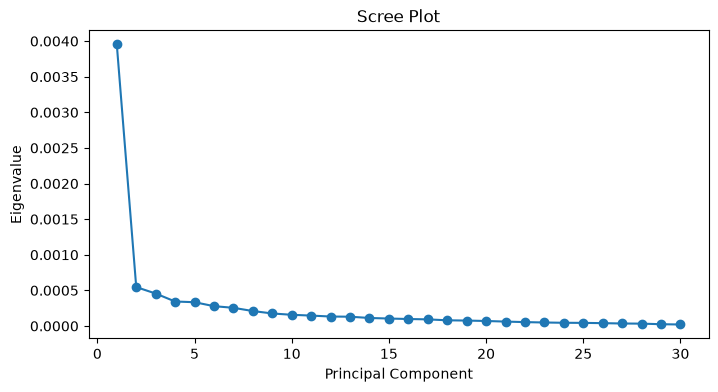

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

plt.plot(
    range(1,len(eigvals)+1),
    eigvals,
    marker='o'
)

plt.xlabel("Principal Component")
plt.ylabel("Eigenvalue")
plt.title("Scree Plot")

plt.show()

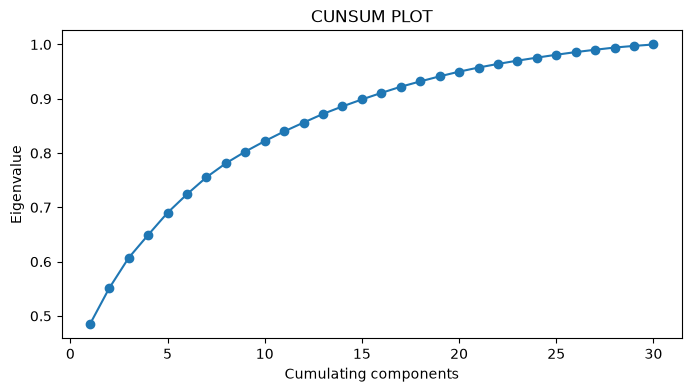

In [28]:
plt.figure(figsize=(8,4))

plt.plot(
    range(1,len(eigvals)+1),
    np.cumsum(explained_variance_ratio),
    marker='o'
)

plt.xlabel("Cumulating components")
plt.ylabel("Eigenvalue")
plt.title("CUNSUM PLOT")

plt.show()

In [29]:
np.cumsum(explained_variance_ratio)/(np.arange(1,len(eigvals)+1)/30)

array([14.52743115,  8.26753806,  6.07019274,  4.8685312 ,  4.14033397,
        3.62086586,  3.23764863,  2.92939319,  2.67574062,  2.46598948,
        2.29061907,  2.14044924,  2.01267281,  1.89847009,  1.79756051,
        1.70775599,  1.62740127,  1.55331068,  1.48630876,  1.42492626,
        1.3679113 ,  1.31484853,  1.26553371,  1.21971019,  1.17733716,
        1.13771536,  1.10034493,  1.06538855,  1.03181859,  1.        ])

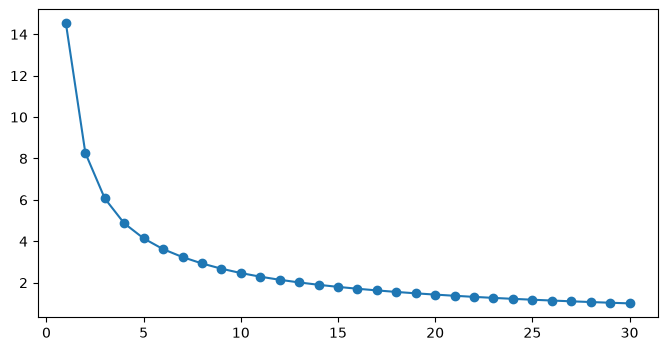

In [30]:
plt.figure(figsize=(8,4))

plt.plot(
    range(1,len(eigvals)+1),
    np.cumsum(explained_variance_ratio)/(np.arange(1,len(eigvals)+1)/30),
    marker='o'
)

plt.xlabel("")
plt.ylabel("")
plt.title("")

plt.show()

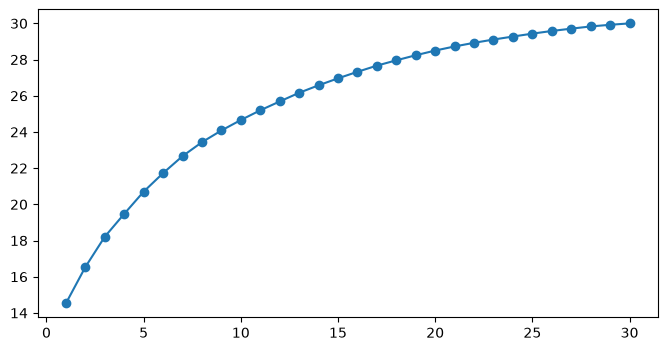

In [31]:
plt.figure(figsize=(8,4))

plt.plot(
    range(1,len(eigvals)+1),
    np.cumsum(explained_variance_ratio)/(1/30),
    marker='o'
)

plt.xlabel("")
plt.ylabel("")
plt.title("")

plt.show()

In [32]:
def pca_covariance(cov, k):

    eigvals, eigvecs = np.linalg.eigh(cov)

    
    idx = np.argsort(eigvals)[::-1]

    eigvals = eigvals[idx]
    eigvecs = eigvecs[:,idx]

    
    eigvals_k = eigvals[:k]
    eigvecs_k = eigvecs[:,:k]
    # factor part
    factor_cov = (
        eigvecs_k
        @ np.diag(eigvals_k)
        @ eigvecs_k.T
    )

    
    residual_var = np.mean(eigvals[k:])

    residual_projection = (
        np.eye(cov.shape[0])
        - eigvecs_k @ eigvecs_k.T
    )

    cov_pca = (
        factor_cov
        + residual_var * residual_projection
    )

    return cov_pca
cov_pca = pca_covariance(
    history.cov().values,
    k=10
)


In [33]:
np.allclose(cov_pca,cov_pca.T)

True

In [34]:
def rolling_min_variance_pca(returns, window=252,k=5):
    portfolio_returns_pca = []
    weights_list_pca = []
    dates_pca = []
    for t in range(window,len(returns)):
        history=returns.iloc[t-window:t]
        cov = history.cov().values
        cov_pca=pca_covariance(cov,k)
        next_return = returns.iloc[t].values
        weights = minimum_weight_of_variance(cov_pca)
        portfolio_return = weights @ next_return
        portfolio_returns_pca.append(portfolio_return)
        weights_list_pca.append(weights)
        dates_pca.append(returns.index[t])
    portfolio_returns = pd.Series(
    portfolio_returns_pca,
    index=dates_pca)
    weights_df = pd.DataFrame(
    weights_list_pca,
    index=dates_pca,
    columns=returns.columns)
    
    return portfolio_returns, weights_df
portfolio_returns_pca, weights_df=rolling_min_variance_pca(returns,window=252,k=10)

In [35]:
weights_df.describe()

,AAPL,AMGN,AMZN,AXP,BA,CAT,CRM,CSCO,CVX,DIS,...,MRK,MSFT,NKE,NVDA,PG,SHW,TRV,UNH,V,WMT
count,3916.000000,3916.000000,3916.000000,3916.000000,3916.000000,3916.000000,3916.000000,3916.000000,3916.000000,3916.000000,...,3916.000000,3916.000000,3916.000000,3916.000000,3916.000000,3916.000000,3916.000000,3916.000000,3916.000000,3916.000000
mean,0.006942,-0.006618,0.035583,-0.024697,-0.010365,-0.013754,0.003795,-0.022975,0.066831,0.042909,...,0.075566,-0.012097,0.004237,-0.004282,0.134468,0.025281,0.058163,0.013017,0.001408,0.137353
std,0.076652,0.073375,0.112043,0.079531,0.050298,0.059125,0.038201,0.063173,0.061134,0.065237,...,0.053710,0.073364,0.050668,0.058350,0.058962,0.055969,0.043041,0.056227,0.047468,0.076459
min,-0.184841,-0.202269,-0.119291,-0.277415,-0.142998,-0.153233,-0.145638,-0.210119,-0.106635,-0.126585,...,-0.047181,-0.200853,-0.150751,-0.255874,-0.051819,-0.101866,-0.228933,-0.158352,-0.111928,-0.032520
25%,-0.040840,-0.044868,-0.018616,-0.071808,-0.043327,-0.044584,-0.020564,-0.063411,0.022253,-0.002528,...,0.039018,-0.063397,-0.026333,-0.020066,0.091432,-0.018343,0.031749,-0.026597,-0.033745,0.083712
50%,0.017740,-0.016818,0.001327,-0.028752,-0.004747,-0.007114,0.001037,-0.020117,0.081340,0.049286,...,0.070074,-0.004996,0.006625,-0.000806,0.129172,0.018562,0.061080,0.018321,-0.000517,0.131012
75%,0.062323,0.026976,0.047510,0.007780,0.023495,0.025915,0.028048,0.021973,0.109677,0.096348,...,0.107191,0.036727,0.028029,0.028607,0.179735,0.065740,0.089158,0.053880,0.040573,0.187953
max,0.225388,0.199376,0.461237,0.215350,0.115739,0.185516,0.135569,0.116420,0.288332,0.193102,...,0.243406,0.154660,0.156807,0.114311,0.257775,0.180445,0.178915,0.146925,0.097979,0.421520


In [36]:
portfolio_returns_pca.describe()

count    3916.000000
mean        0.000543
std         0.008473
min        -0.090778
25%        -0.003526
50%         0.000676
75%         0.004704
max         0.087255
dtype: float64

In [37]:
pca_gross = weights_df.abs().sum(axis=1)

pca_max_abs = weights_df.abs().max(axis=1)

pca_negative_count = (weights_df < 0).sum(axis=1)

pca_turnover = (
    0.5 *
    weights_df.diff().abs().sum(axis=1, min_count=1)
)

In [38]:
pca_gross.describe()

count    3916.000000
mean        1.996322
std         0.494448
min         1.180946
25%         1.673272
50%         1.890339
75%         2.174171
max         3.547825
dtype: float64

In [39]:
pca_max_abs.describe()

count    3916.000000
mean        0.208605
std         0.068912
min         0.100451
25%         0.173569
50%         0.191246
75%         0.227505
max         0.461237
dtype: float64

In [40]:
pca_negative_count.describe()

count    3916.000000
mean       10.879980
std         2.056767
min         5.000000
25%         9.000000
50%        11.000000
75%        12.000000
max        17.000000
dtype: float64

In [41]:
pca_turnover.describe()

count    3915.000000
mean        0.043025
std         0.045277
min         0.001900
25%         0.018974
50%         0.031169
75%         0.051198
max         0.750013
dtype: float64

In [42]:
#k=5
portfolio_returns_k5, weights_df_k5=rolling_min_variance_pca(returns,window=252,k=5)
pca_gross_k5 = weights_df_k5.abs().sum(axis=1)

pca_max_abs_k5 = weights_df_k5.abs().max(axis=1)

pca_negative_count_k5 = (weights_df_k5 < 0).sum(axis=1)

pca_turnover_k5 = (
    0.5 *
    weights_df_k5.diff().abs().sum(axis=1, min_count=1)
)
print(pca_gross_k5.describe())
print(pca_max_abs_k5.describe())
print(pca_negative_count_k5.describe())
print(pca_turnover_k5.describe())

count    3916.000000
mean        1.893831
std         0.449596
min         1.208881
25%         1.608290
50%         1.789414
75%         2.042494
max         3.358175
dtype: float64
count    3916.000000
mean        0.181593
std         0.049038
min         0.095692
25%         0.151765
50%         0.170700
75%         0.208302
max         0.345792
dtype: float64
count    3916.000000
mean       10.115679
std         1.800993
min         5.000000
25%         9.000000
50%        10.000000
75%        11.000000
max        15.000000
dtype: float64
count    3915.000000
mean        0.032767
std         0.038397
min         0.001483
25%         0.013149
50%         0.022433
75%         0.039718
max         0.577165
dtype: float64


In [43]:
#k=15
portfolio_returns_k15, weights_df_k15=rolling_min_variance_pca(returns,window=252,k=15)
pca_gross_k15 = weights_df_k15.abs().sum(axis=1)

pca_max_abs_k15 = weights_df_k15.abs().max(axis=1)

pca_negative_count_k15 = (weights_df_k15 < 0).sum(axis=1)

pca_turnover_k15 = (
    0.5 *
    weights_df_k15.diff().abs().sum(axis=1, min_count=1)
)
print(pca_gross_k15.describe())
print(pca_max_abs_k15.describe())
print(pca_negative_count_k15.describe())
print(pca_turnover_k15.describe())

count    3916.000000
mean        2.059763
std         0.494783
min         1.249951
25%         1.790096
50%         1.947305
75%         2.274970
max         3.710100
dtype: float64
count    3916.000000
mean        0.225366
std         0.068483
min         0.104699
25%         0.190411
50%         0.211360
75%         0.245261
max         0.497123
dtype: float64
count    3916.000000
mean       10.910623
std         2.154844
min         5.000000
25%         9.000000
50%        11.000000
75%        12.000000
max        17.000000
dtype: float64
count    3915.000000
mean        0.048809
std         0.047190
min         0.002061
25%         0.021989
50%         0.036111
75%         0.058606
max         0.659928
dtype: float64


In [44]:
#k=20
portfolio_returns_k20, weights_df_k20=rolling_min_variance_pca(returns,window=252,k=20)
pca_gross_k20 = weights_df_k20.abs().sum(axis=1)

pca_max_abs_k20 = weights_df_k20.abs().max(axis=1)

pca_negative_count_k20 = (weights_df_k20 < 0).sum(axis=1)

pca_turnover_k20 = (
    0.5 *
    weights_df_k20.diff().abs().sum(axis=1, min_count=1)
)
print(pca_gross_k20.describe())
print(pca_max_abs_k20.describe())
print(pca_negative_count_k20.describe())
print(pca_turnover_k20.describe())

count    3916.000000
mean        2.095737
std         0.509995
min         1.250066
25%         1.816909
50%         2.053995
75%         2.359140
max         4.004035
dtype: float64
count    3916.000000
mean        0.243732
std         0.069409
min         0.102577
25%         0.199876
50%         0.236108
75%         0.271885
max         0.545303
dtype: float64
count    3916.000000
mean       10.918284
std         2.380414
min         5.000000
25%         9.000000
50%        11.000000
75%        12.000000
max        17.000000
dtype: float64
count    3915.000000
mean        0.051025
std         0.048090
min         0.002185
25%         0.023391
50%         0.038935
75%         0.062524
max         0.763853
dtype: float64


In [45]:
vol_5 = portfolio_returns_k5.std() * np.sqrt(252)
vol_10 = portfolio_returns_pca.std() * np.sqrt(252)
vol_15 = portfolio_returns_k15.std() * np.sqrt(252)
vol_20 = portfolio_returns_k20.std() * np.sqrt(252)

In [46]:
print(vol_5)
print(vol_10)
print(vol_15)
print(vol_20)

0.13610935469972377
0    0.134713
dtype: float64
0.13485570068074362
0.1344121853849496


In [47]:
pca_summary = pd.DataFrame({
    "annual_vol": [
        0.1361093547,
        0.1345053851,
        0.1348557007,
        0.1344121854
    ],

    "mean_gross": [
        1.893831,
        1.996322,
        2.059763,
        2.095737
    ],

    "mean_max_abs_weight": [
        0.181593,
        0.208605,
        0.225366,
        0.243732
    ],

    "mean_turnover": [
        0.032767,
        0.043025,
        0.048809,
        0.051025
    ]
},
index=[5, 10, 15, 20])

pca_summary.index.name = "k"

pca_summary

,annual_vol,mean_gross,mean_max_abs_weight,mean_turnover
k,,,,
5,0.136109,1.893831,0.181593,0.032767
10,0.134505,1.996322,0.208605,0.043025
15,0.134856,2.059763,0.225366,0.048809
20,0.134412,2.095737,0.243732,0.051025


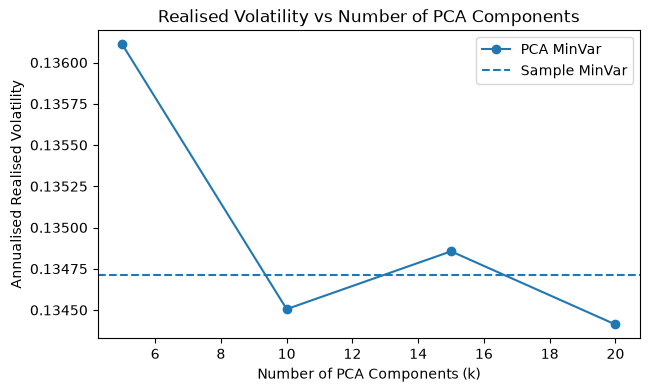

In [48]:
plt.figure(figsize=(7, 4))

plt.plot(
    pca_summary.index,
    pca_summary["annual_vol"],
    marker="o",
    label="PCA MinVar"
)

plt.axhline(
    0.1347129,
    linestyle="--",
    label="Sample MinVar"
)

plt.xlabel("Number of PCA Components (k)")
plt.ylabel("Annualised Realised Volatility")
plt.title("Realised Volatility vs Number of PCA Components")

plt.legend()
plt.show()

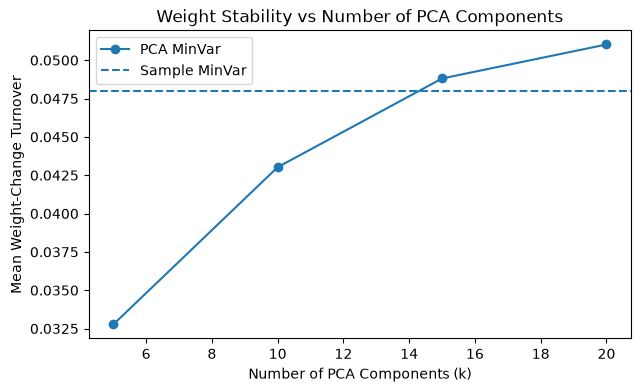

In [49]:
plt.figure(figsize=(7, 4))

plt.plot(
    pca_summary.index,
    pca_summary["mean_turnover"],
    marker="o",
    label="PCA MinVar"
)

plt.axhline(
    0.047996,
    linestyle="--",
    label="Sample MinVar"
)

plt.xlabel("Number of PCA Components (k)")
plt.ylabel("Mean Weight-Change Turnover")
plt.title("Weight Stability vs Number of PCA Components")

plt.legend()
plt.show()

Across \(k=5,10,15,20\), realised volatility remains remarkably stable at approximately 13.4–13.6%, while portfolio turnover increases substantially as more principal components are retained. This suggests that the additional covariance structure captured at larger \(k\) has a much stronger effect on portfolio weights than on out-of-sample risk. Stronger PCA regularisation therefore produces more stable portfolios at relatively little cost in realised volatility.


In [50]:
def one_step_drifted_turnover(
    previous_weights,
    asset_returns,
    target_weights
):
    portfolio_return=previous_weights@asset_returns
    asset_new_value=previous_weights*(1+asset_returns)
    portfolio_new_value=1+portfolio_return
    drifted_weights=asset_new_value/portfolio_new_value
    drift_turnover=(1/2*(np.abs(drifted_weights-target_weights))).sum()
    return drifted_weights,drift_turnover

In [51]:
def rolling_drifted_turnover(weights, returns):

    turnover_list = []
    dates = []

    for t in range(1, len(weights)):

        previous_weights = weights.iloc[t - 1].values

        previous_date = weights.index[t - 1]

        asset_returns = returns.loc[previous_date]

        target_weights = weights.iloc[t].values

        drifted_weights, drift_turnover = (
            one_step_drifted_turnover(
                previous_weights,
                asset_returns,
                target_weights
            )
        )

        turnover_list.append(drift_turnover)
        dates.append(weights.index[t])

    turnover_series = pd.Series(
        turnover_list,
        index=dates,
        name="drifted_turnover"
    )

    return turnover_series
ars=rolling_drifted_turnover(weights_df,returns)
ars

2011-01-05 00:00:00+00:00    0.082199
2011-01-06 00:00:00+00:00    0.051573
2011-01-07 00:00:00+00:00    0.045717
2011-01-10 00:00:00+00:00    0.011362
2011-01-11 00:00:00+00:00    0.059274
                               ...   
2026-07-27 00:00:00+00:00    0.033593
2026-07-28 00:00:00+00:00    0.028467
2026-07-29 00:00:00+00:00    0.049498
2026-07-30 00:00:00+00:00    0.015370
2026-07-31 00:00:00+00:00    0.026115
Name: drifted_turnover, Length: 3915, dtype: float64

In [52]:
ars.describe()

count    3915.000000
mean        0.045040
std         0.045124
min         0.003690
25%         0.021078
50%         0.032888
75%         0.053260
max         0.750307
Name: drifted_turnover, dtype: float64

In [53]:
arsn=rolling_drifted_turnover(weights,returns)
arsn.describe()

count    3915.000000
mean        0.049846
std         0.048260
min         0.003521
25%         0.022604
50%         0.037636
75%         0.061104
max         0.721709
Name: drifted_turnover, dtype: float64

In [54]:
#None PCA
arsn.quantile([0.90, 0.95, 0.99])

0.90    0.091949
0.95    0.123844
0.99    0.259171
Name: drifted_turnover, dtype: float64

In [55]:
#PCA
ars.quantile([0.90, 0.95, 0.99])

0.90    0.083415
0.95    0.115707
0.99    0.231124
Name: drifted_turnover, dtype: float64

In [56]:
arsp=rolling_drifted_turnover(weights_equal,returns)

In [57]:
arsp.describe()

count    3915.000000
mean        0.004356
std         0.001919
min         0.001314
25%         0.003136
50%         0.003948
75%         0.005102
max         0.026351
Name: drifted_turnover, dtype: float64

In [58]:
arsp.quantile([0.90, 0.95, 0.99])

0.90    0.006661
0.95    0.007722
0.99    0.010737
Name: drifted_turnover, dtype: float64

In [59]:
summary = pd.DataFrame({
    "Equal Weight": [
        0.167648,
        1.0,
        1/30,
        0.0,
        0.004356
    ],

    "Sample MinVar": [
        0.134713,
        2.089324,
        0.282618,
        0.047996,
        0.049846
    ],

    "PCA MinVar (k=10)": [
        0.134505,
        1.996322,
        0.208605,
        0.043025,
        0.045040
    ]
},
index=[
    "Annualised realised volatility",
    "Mean gross exposure",
    "Mean max absolute weight",
    "Mean target-weight turnover",
    "Mean drifted turnover"
])

summary

,Equal Weight,Sample MinVar,PCA MinVar (k=10)
Annualised realised volatility,0.167648,0.134713,0.134505
Mean gross exposure,1.000000,2.089324,1.996322
Mean max absolute weight,0.033333,0.282618,0.208605
Mean target-weight turnover,0.000000,0.047996,0.043025
Mean drifted turnover,0.004356,0.049846,0.045040


In [60]:

print(portfolio_returns_equal)

print(portfolio_returns)

print(portfolio_returns_pca)

2011-01-04 00:00:00+00:00   -0.000296
2011-01-05 00:00:00+00:00    0.008950
2011-01-06 00:00:00+00:00    0.005148
2011-01-07 00:00:00+00:00   -0.000922
2011-01-10 00:00:00+00:00   -0.000955
                               ...   
2026-07-27 00:00:00+00:00    0.009306
2026-07-28 00:00:00+00:00    0.016811
2026-07-29 00:00:00+00:00   -0.013266
2026-07-30 00:00:00+00:00    0.003062
2026-07-31 00:00:00+00:00    0.007102
Name: equal_weight_return, Length: 3916, dtype: float64
                                  0
2011-01-04 00:00:00+00:00 -0.004061
2011-01-05 00:00:00+00:00 -0.008846
2011-01-06 00:00:00+00:00 -0.005808
2011-01-07 00:00:00+00:00 -0.004586
2011-01-10 00:00:00+00:00 -0.004675
...                             ...
2026-07-27 00:00:00+00:00  0.004510
2026-07-28 00:00:00+00:00  0.009356
2026-07-29 00:00:00+00:00 -0.006980
2026-07-30 00:00:00+00:00  0.009315
2026-07-31 00:00:00+00:00  0.013246

[3916 rows x 1 columns]
2011-01-04 00:00:00+00:00   -0.009888
2011-01-05 00:00:00+00:00   -0.

In [61]:
print(portfolio_returns_equal.shape)
print(portfolio_returns_equal.dtype)
print(portfolio_returns_equal.head())

(3916,)
float64
2011-01-04 00:00:00+00:00   -0.000296
2011-01-05 00:00:00+00:00    0.008950
2011-01-06 00:00:00+00:00    0.005148
2011-01-07 00:00:00+00:00   -0.000922
2011-01-10 00:00:00+00:00   -0.000955
Name: equal_weight_return, dtype: float64


In [62]:
ROLLING_VOL_WINDOW = 63
sample_returns = portfolio_returns.iloc[:, 0]
equal_rolling_vol = (
    portfolio_returns_equal.rolling(ROLLING_VOL_WINDOW ).std()
    * np.sqrt(252)
)

sample_rolling_vol = (
    sample_returns.rolling(ROLLING_VOL_WINDOW ).std()
    * np.sqrt(252)
)

pca_rolling_vol = (
    portfolio_returns_pca.rolling(ROLLING_VOL_WINDOW ).std()
    * np.sqrt(252)
)

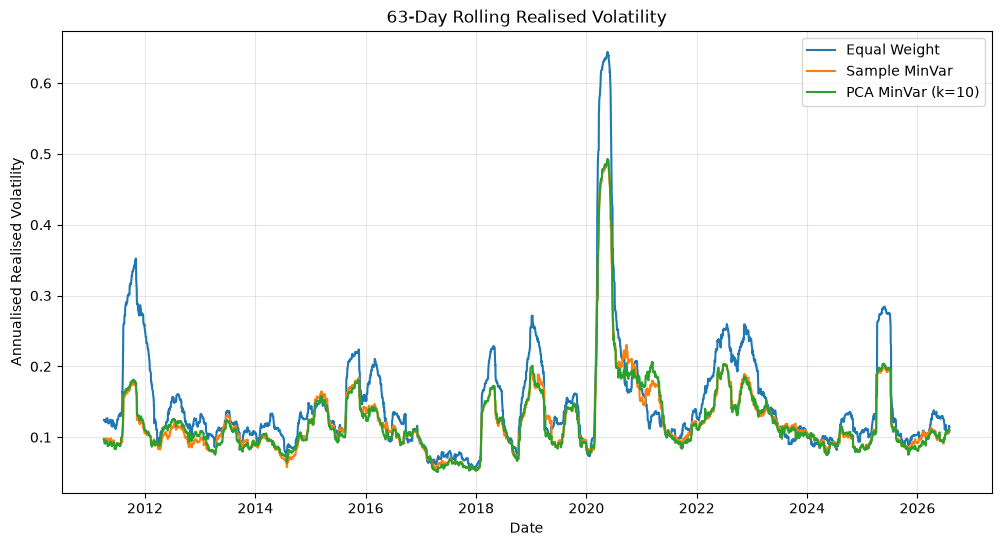

In [63]:
plt.figure(figsize=(12, 6))

plt.plot(
    equal_rolling_vol.index,
    equal_rolling_vol,
    label="Equal Weight"
)

plt.plot(
    sample_rolling_vol.index,
    sample_rolling_vol,
    label="Sample MinVar"
)

plt.plot(
    pca_rolling_vol.index,
    pca_rolling_vol,
    label="PCA MinVar (k=10)"
)

plt.xlabel("Date")
plt.ylabel("Annualised Realised Volatility")
plt.title("63-Day Rolling Realised Volatility")

plt.legend()
plt.grid(alpha=0.3)

plt.show()


In [64]:

rolling_vol_difference = (
    pca_rolling_vol - sample_rolling_vol
)

rolling_vol_difference.describe()

count    3854.000000
mean       -0.000563
std         0.006850
min        -0.031786
25%        -0.003903
50%        -0.000610
75%         0.002969
max         0.029311
dtype: float64

In [65]:
rolling_vol_difference.abs().mean()

np.float64(0.004796632524602003)

In [66]:
equal_wealth = (1 + portfolio_returns_equal).cumprod()
sample_wealth = (1 + sample_returns).cumprod()
pca_wealth = (1 + portfolio_returns_pca).cumprod()

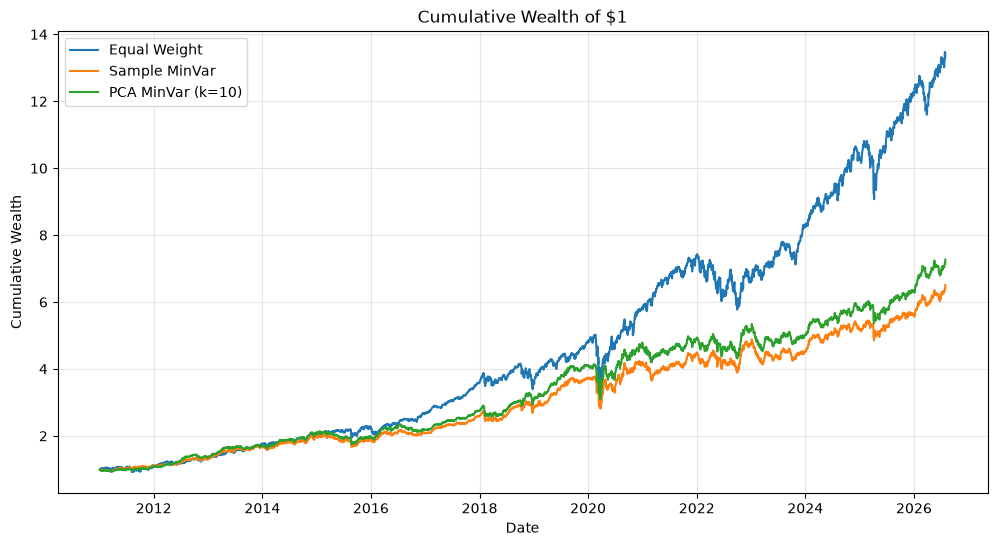

In [67]:
plt.figure(figsize=(12, 6))

plt.plot(
    equal_wealth.index,
    equal_wealth,
    label="Equal Weight"
)

plt.plot(
    sample_wealth.index,
    sample_wealth,
    label="Sample MinVar"
)

plt.plot(
    pca_wealth.index,
    pca_wealth,
    label="PCA MinVar (k=10)"
)

plt.xlabel("Date")
plt.ylabel("Cumulative Wealth")
plt.title("Cumulative Wealth of $1")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [68]:
terminal_wealth = pd.Series({
    "Equal Weight": equal_wealth.iloc[-1],
    "Sample MinVar": sample_wealth.iloc[-1],
    "PCA MinVar (k=10)": pca_wealth.iloc[-1]
})

terminal_wealth

Equal Weight         13.431440
Sample MinVar         6.511913
PCA MinVar (k=10)     7.269295
dtype: float64

In [70]:
years = len(portfolio_returns_equal) / 252

cagr = pd.Series({
    "Equal Weight":
        equal_wealth.iloc[-1] ** (1 / years) - 1,

    "Sample MinVar":
        sample_wealth.iloc[-1] ** (1 / years) - 1,

    "PCA MinVar (k=10)":
        pca_wealth.iloc[-1] ** (1 / years) - 1
})

cagr

Equal Weight         0.181942
Sample MinVar        0.128141
PCA MinVar (k=10)    0.136157
dtype: float64

In [71]:
summary = pd.DataFrame({
    "Equal Weight": [
        0.167648,
        0.181942,
        13.431440,
        1.000000,
        1 / 30,
        0.000000,
        0.004356
    ],

    "Sample MinVar": [
        0.134713,
        0.128141,
        6.511913,
        2.089324,
        0.282618,
        0.047996,
        0.049846
    ],

    "PCA MinVar (k=10)": [
        0.134505,
        0.136157,
        7.269295,
        1.996322,
        0.208605,
        0.043025,
        0.045040
    ]
},
index=[
    "Annualised realised volatility",
    "CAGR",
    "Terminal wealth",
    "Mean gross exposure",
    "Mean max absolute weight",
    "Mean target-weight turnover",
    "Mean drifted turnover"
])

summary

,Equal Weight,Sample MinVar,PCA MinVar (k=10)
Annualised realised volatility,0.167648,0.134713,0.134505
CAGR,0.181942,0.128141,0.136157
Terminal wealth,13.431440,6.511913,7.269295
Mean gross exposure,1.000000,2.089324,1.996322
Mean max absolute weight,0.033333,0.282618,0.208605
Mean target-weight turnover,0.000000,0.047996,0.043025
Mean drifted turnover,0.004356,0.049846,0.045040
